## Anamoly Detection..

-   Unusual Patterns..which is very far from actual from actual patterns...
- Ex : outliers, and fraud detection (credit card fraud detection ..)

## Isolation Forest
- it is a unsupervised ml algorithm that comes under ensemble technique , which helps in detecting anomoly using the decission trees...
- it isolates the anomoly using the forest(decission trees)


### how to detect anomolies.?
* We can detect anomlies using the Isolation Forest..then explain the Isolation Forest and its working with example..
* it will use mutiple decission trees and selects random root nodes and then calculates the depth of each values.. , using the depth values , it will find the average of each values..and then conclude if the avg of the value is : 
    - far then - Normal value
    - near : anomoly

In [ ]:
from sklearn.ensemble import IsolationForest

anomoly = IsolationForest(random_state=42,contamination=float)
# contamination = float : to detect the n% of outliers..

# anomoly.fit(df)

# anomoly.predict(df) -> anomoly or Normal
# anomoly.fit_predict(df) -> anomoly or Normal

## use encodings if  df has it has categorical values.. before the fit() 

## Before PCA , use scaling techniques for 

## we can use PCA and anomoly 

In [ ]:
## download any sentence based datasets.
## download any clustering datasets..

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [9]:
df = pd.read_csv('../datasets/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
print(df.shape)
print(df['Class'].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print('Shape of X before :', X_scaled.shape)
print('Shape of X afterward : ', X_pca.shape)

Shape of X before : (284807, 30)
Shape of X afterward :  (284807, 27)


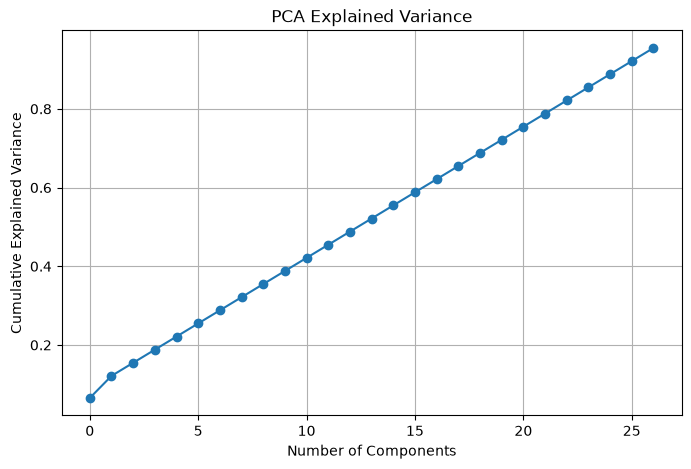

In [21]:
plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_),
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [23]:
## train isolation forest..

iso = IsolationForest(contamination=0.0017, random_state=42)

iso.fit(X_pca)
iso

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.0017
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [27]:
## predict the methods..

iso.predict(X_pca)

array([1, 1, 1, ..., 1, 1, 1], shape=(284807,))

In [28]:
pred = iso.predict(X_pca)

pred = np.where(pred == -1, 1, 0)

In [29]:
print(confusion_matrix(y, pred))

[[283923    392]
 [   399     93]]


In [30]:
print(classification_report(y, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.19      0.19      0.19       492

    accuracy                           1.00    284807
   macro avg       0.60      0.59      0.59    284807
weighted avg       1.00      1.00      1.00    284807



In [31]:
print("Detected Fraud Cases :", np.sum(pred == 1))

print("Actual Fraud Cases :", np.sum(y == 1))

Detected Fraud Cases : 485
Actual Fraud Cases : 492
